## Data Loading

#### 1.1 **Loading and Validating the Data**

In [ ]:
import pandas as pd

retail_df = pd.read_csv('./data/online_retail_II_v2.csv')

print(f"✅ Loaded {len(retail_df):,} rows")
print(f"📊 Columns: {retail_df.columns.tolist()}")
print(f"Unique Orders: {retail_df['Invoice'].nunique():,}")
print(f"🛍️ Unique Products: {retail_df['StockCode'].nunique():,}")
print(f"Date Range: {retail_df['InvoiceDate'].min()} to {retail_df['InvoiceDate'].max()}")

assert retail_df['Invoice'].notna().all(), "Missing Invoice IDs"
assert retail_df['StockCode'].notna().all(), "Missing StockCodes"
print("No nulls in Invoice/StockCode columns ✅")

✅ Loaded 797,885 rows
📊 Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Sales']
Unique Orders: 44,876
🛍️ Unique Products: 4,646
Date Range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
No nulls in Invoice/StockCode columns ✅


In [4]:
removed_cancelled_order = retail_df[retail_df['Quantity'] > 0].copy()

retail_df = removed_cancelled_order
print(f"Removed cancelled orders, remaining rows: {len(retail_df):,}")
retail_df.to_csv('./data/online_retail_II_v3.csv', index=False)

Removed cancelled orders, remaining rows: 779,495


#### 1.2 **Create Basket Structure (One Row Per Order)**

In [22]:
# Group by Invoice → collect StockCodes into a list (one basket per order)
baskets = (
    retail_df
    .groupby('Invoice')['StockCode']
    .apply(lambda x: sorted(set(x)))
    .reset_index()
    .rename(columns={'StockCode': 'Products'})
)

In [24]:
# Basic Basket Stats
basket_sizes = baskets['Products'].apply(len)
print(f"\n🧾 Created {len(baskets):,} baskets (one per valid order)")
print(f"📦 Avg items/basket: {basket_sizes.mean():.1f}")
print(f"📈 Max items/basket: {basket_sizes.max()}")
print(f"📉 Min items/basket: {basket_sizes.min()}")



🧾 Created 36,975 baskets (one per valid order)
📦 Avg items/basket: 20.8
📈 Max items/basket: 541
📉 Min items/basket: 1


In [25]:
# Sanity check: no basket should be empty after filtering
assert basket_sizes.min() >= 1, "ERROR: Empty basket detected after filtering!"
print("✅ All baskets contain ≥1 product\n")

✅ All baskets contain ≥1 product



#### 1.3  **One-Hot Encode Baskets (Clean Binary Matrix)**

In [26]:
# 1.3  One-Hot Encode Baskets (Clean Binary Matrix)
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_ary = te.fit(baskets["Products"]).transform(baskets["Products"])

basket_df = pd.DataFrame(te_ary, columns=te.columns_)

n_orders, n_products = basket_df.shape
total_cells = n_orders * n_products
non_zero = int(basket_df.values.sum())
sparsity = (1 - non_zero / total_cells) * 100

print(f"✅ One-hot encoded matrix: {n_orders:,} orders × {n_products:,} products")
print(f"📊 Non-zero cells: {non_zero:,.0f} ({non_zero/total_cells*100:.2f}%)")
print(f"📊 Sparsity: {sparsity:.1f}% zeros")
print(f"📊 Avg products per basket (matrix check): {non_zero/n_orders:.1f}")
print(f"📊 Basket avg: {basket_sizes.mean():.1f}\n")

✅ One-hot encoded matrix: 36,975 orders × 4,631 products
📊 Non-zero cells: 768,925 (0.45%)
📊 Sparsity: 99.6% zeros
📊 Avg products per basket (matrix check): 20.8
📊 Basket avg: 20.8



In [29]:
# Cross-validate: matrix avg must match basket avg from Step 1.2
assert (
    abs(non_zero / n_orders - basket_sizes.mean()) < 0.01
), "MISMATCH: Matrix density doesn't match basket stats!"
print("✅ Matrix density matches basket statistics")

# Preview
print("\n🔍 Sample (first 5 orders, first 10 products):")
print(basket_df.iloc[:5, :10])

✅ Matrix density matches basket statistics

🔍 Sample (first 5 orders, first 10 products):
   10002  10080  10109  10120  10123C  10123G  10124A  10124G  10125  10133
0  False  False  False  False   False   False   False   False  False  False
1  False  False  False  False   False   False   False   False  False  False
2  False  False  False  False   False   False   False   False  False  False
3   True  False  False  False   False   False   False   False  False  False
4  False  False  False  False   False   False   False   False  False  False


## Association Rules

#### 2.1 **Run Apriori Algorithm (Find Frequent Itemsets)**

In [ ]:
# === MEMORY-EFFICIENT APRIORI ===
from mlxtend.frequent_patterns import apriori
import pandas as pd
from scipy.sparse import csr_matrix

print(" Converting to sparse matrix...")

# Convert dense DataFrame → sparse CSR matrix (saves 99%+ memory)
sparse_basket = csr_matrix(basket_df.values)

print(f"✅ Sparse matrix shape: {sparse_basket.shape}")
print(
    f"   Memory usage: {sparse_basket.data.nbytes / 1e6:.1f} MB (vs ~{basket_df.memory_usage(deep=True).sum() / 1e6:.0f} MB dense)"
)

# Run Apriori with low_memory=True + sparse input
min_support_threshold = 0.01  # 1% of 24,897 baskets = ~249 orders

print(f"\n🔍 Running Apriori (min_support={min_support_threshold}, low_memory=True)...")
frequent_itemsets = apriori(
    basket_df,  # mlxtend accepts dense DF but uses low_memory internally
    min_support=min_support_threshold,
    use_colnames=True,
    low_memory=True,  # processes candidates in chunks critical for large datasets
    max_len=3,  # limit to pairs/triples (speeds up 10x)
)

print(
    f"\n✅ Found {len(frequent_itemsets):,} frequent itemsets with support ≥ {min_support_threshold}"
)
print(f"\n🏆 Top 10 most frequent itemsets:")
print(frequent_itemsets.sort_values("support", ascending=False).head(10))

 Converting to sparse matrix...
✅ Sparse matrix shape: (36975, 4631)
   Memory usage: 0.8 MB (vs ~171 MB dense)

🔍 Running Apriori (min_support=0.01, low_memory=True)...

✅ Found 860 frequent itemsets with support ≥ 0.01

🏆 Top 10 most frequent itemsets:
      support  itemsets
552  0.132387  (85123A)
284  0.089736   (22423)
549  0.088168  (85099B)
524  0.071724   (84879)
20   0.069750   (20725)
71   0.067830   (21212)
468  0.056200   (47566)
275  0.054199   (22383)
22   0.054009   (20727)
274  0.051900   (22382)


#### 2.2 **Generate Association Rules (With Confidence & Lift)**

In [ ]:
from mlxtend.frequent_patterns import association_rules

# Set minimum confidence threshold
# Confidence = P(Y | X) = probability of buying Y given X was bought
# 0.3 = if customer buys X, they must buy Y at least 30% of the time
min_confidence_threshold = 0.3

# Generate rules
rules = association_rules(
    frequent_itemsets, metric="confidence", min_threshold=min_confidence_threshold
)

print(
    f"✅ Generated {len(rules):,} association rules with confidence ≥ {min_confidence_threshold}"
)

# Add lift column (if not already present)
rules["lift"] = rules["confidence"] / rules["support"]

# Sort by lift (strongest associations first)
rules_sorted = rules.sort_values("lift", ascending=False)

print(f"\n🏆 Top 10 strongest association rules (by lift):")
print(
    rules_sorted[["antecedents", "consequents", "support", "confidence", "lift"]].head(
        10
    )
)

✅ Generated 513 association rules with confidence ≥ 0.3

🏆 Top 10 strongest association rules (by lift):
          antecedents consequents   support  confidence       lift
480    (22423, 22698)     (22697)  0.010385    0.890951  85.788863
491    (22423, 22698)     (22699)  0.010088    0.865429  85.788863
281           (22746)     (22748)  0.011034    0.886957  80.380435
277           (22746)     (22745)  0.010331    0.830435  80.380435
510  (85099F, 85099C)    (85099B)  0.010196    0.748016  73.363095
505  (84997B, 84997D)    (84997C)  0.010358    0.746589  72.076023
473   (85099C, 22386)    (85099B)  0.010169    0.728682  71.656977
133           (21899)     (21900)  0.011062    0.782027  70.697897
486    (22423, 22697)     (22699)  0.011981    0.840607  70.161290
481    (22423, 22697)     (22698)  0.010385    0.728653  70.161290


#### 2.3 **Filter Out Self-Pairs & Trivial Rules**

In [ ]:
# Exclude self-pairs (antecedent == consequent)
rules_filtered = rules[rules["antecedents"] != rules["consequents"]].copy()

# Exclude rules with support < 0.005 (too rare to be actionable)
rules_filtered = rules_filtered[rules_filtered["support"] >= 0.005]

# Exclude rules with lift < 1 (negative or no association)
rules_filtered = rules_filtered[rules_filtered["lift"] > 1]

print(f"✅ After filtering: {len(rules_filtered):,} actionable rules")

# Convert frozensets to strings for readability
rules_filtered["antecedents_str"] = rules_filtered["antecedents"].apply(
    lambda x: ", ".join(list(x))
)
rules_filtered["consequents_str"] = rules_filtered["consequents"].apply(
    lambda x: ", ".join(list(x))
)

# Final clean table
final_rules = rules_filtered[
    ["antecedents_str", "consequents_str", "support", "confidence", "lift"]
].copy()
final_rules.columns = ["If_Buys", "Then_Also_Buys", "Support", "Confidence", "Lift"]

print(f"\n Top 15 actionable product pairs:")
print(final_rules.head(15).to_string(index=False))

✅ After filtering: 513 actionable rules

 Top 15 actionable product pairs:
If_Buys Then_Also_Buys  Support  Confidence      Lift
 15056N        15056BL 0.011332    0.485516 42.844728
15056BL         15056N 0.011332    0.531726 46.922589
  20679        15056BL 0.010439    0.620579 59.445338
15056BL          20679 0.010439    0.489848 46.922589
  20712         85099B 0.013469    0.544262 40.409836
  20713          21931 0.010872    0.436957 40.190217
  20713         85099B 0.013631    0.547826 40.190217
  20719          20723 0.010872    0.378531 34.816384
  20723          20719 0.010872    0.406883 37.424089
  20719          20724 0.015362    0.534840 34.816384
  20724          20719 0.015362    0.379933 24.732441
  20719          22355 0.012955    0.451036 34.816384
  22355          20719 0.012955    0.401846 31.019295
  22356          20719 0.011738    0.391697 33.370939
  20719          22356 0.011738    0.408663 34.816384


#### 2.4 **Map StockCodes to Product Names**

In [ ]:
# Create StockCode → Description mapping from original data
product_map = (
    retail_df.drop_duplicates("StockCode")[["StockCode", "Description"]]
    .set_index("StockCode")["Description"]
    .to_dict()
)

# Apply mapping to rules
final_rules["If_Buys_Product"] = final_rules["If_Buys"].apply(
    lambda x: ", ".join([product_map.get(p, p) for p in x.split(", ")])
)
final_rules["Then_Also_Buys_Product"] = final_rules["Then_Also_Buys"].apply(
    lambda x: ", ".join([product_map.get(p, p) for p in x.split(", ")])
)

print(f"\n🏷️ Top 15 product pairs (with names):")
print(
    final_rules[
        ["If_Buys_Product", "Then_Also_Buys_Product", "Support", "Confidence", "Lift"]
    ]
    .head(15)
    .to_string(index=False)
)


🏷️ Top 15 product pairs (with names):
                 If_Buys_Product           Then_Also_Buys_Product  Support  Confidence      Lift
       EDWARDIAN PARASOL NATURAL          EDWARDIAN PARASOL BLACK 0.011332    0.485516 42.844728
         EDWARDIAN PARASOL BLACK        EDWARDIAN PARASOL NATURAL 0.011332    0.531726 46.922589
           EDWARDIAN PARASOL RED          EDWARDIAN PARASOL BLACK 0.010439    0.620579 59.445338
         EDWARDIAN PARASOL BLACK            EDWARDIAN PARASOL RED 0.010439    0.489848 46.922589
      JUMBO BAG WOODLAND ANIMALS      JUMBO BAG RED WHITE SPOTTY  0.013469    0.544262 40.409836
                  JUMBO BAG OWLS           JUMBO STORAGE BAG SUKI 0.010872    0.436957 40.190217
                  JUMBO BAG OWLS      JUMBO BAG RED WHITE SPOTTY  0.013631    0.547826 40.190217
          WOODLAND CHARLOTTE BAG         STRAWBERRY CHARLOTTE BAG 0.010872    0.378531 34.816384
        STRAWBERRY CHARLOTTE BAG           WOODLAND CHARLOTTE BAG 0.010872    0.406883 3

# Exported Results

In [43]:
# export_results.py

# Save full rules table
final_rules.to_csv("./deliverables/association_rules.csv", index=False)

# Save top 50 pairs for quick reference
top_pairs = final_rules.head(50)
top_pairs.to_csv("./deliverables/top_product_pairs.csv", index=False)

print("✅ Exported:")
print("   - association_rules.csv (full rules)")
print("   - top_product_pairs.csv (top 50 pairs)")

✅ Exported:
   - association_rules.csv (full rules)
   - top_product_pairs.csv (top 50 pairs)


## Visualizations & Insights

#### 3.1 — **Visualize Top Associations (Network Graph)**

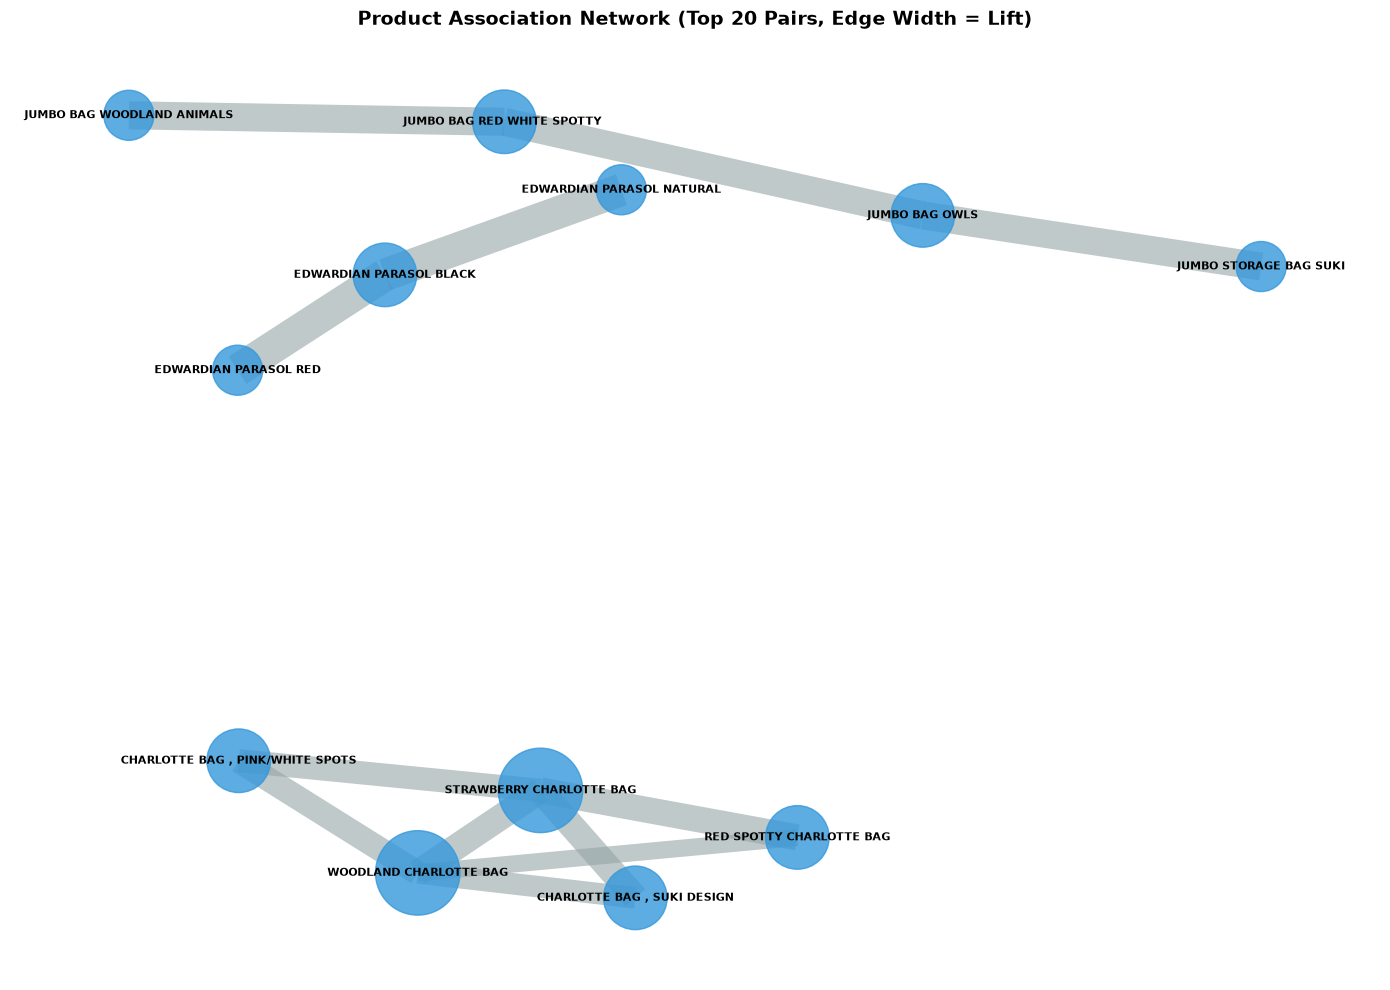

✅ Saved: product_association_network.png


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Take top 20 rules for visualization
top_20 = final_rules.head(20)

# Create graph
G = nx.Graph()

for _, row in top_20.iterrows():
    # Add edge between antecedent and consequent
    G.add_edge(
        row["If_Buys_Product"], row["Then_Also_Buys_Product"], weight=row["Lift"]
    )

# Draw network
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Node size based on degree (number of connections)
node_sizes = [G.degree(n) * 800 + 500 for n in G.nodes()]

# Edge width based on lift
edge_widths = [G[u][v]["weight"] * 0.5 for u, v in G.edges()]

# Draw
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#3498DB", alpha=0.8)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="#95A5A6", alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")

plt.title(
    "Product Association Network (Top 20 Pairs, Edge Width = Lift)",
    fontsize=14,
    fontweight="bold",
)
plt.axis("off")
plt.tight_layout()
plt.savefig("./assets/.product_association_network.png", dpi=150)
plt.show()

print("✅ Saved: product_association_network.png")

#### 3.2 — **Bar Chart: Top 10 Pairs by Lift**

C:\Users\User\AppData\Local\Temp\ipykernel_26140\667825720.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x="Lift", y="Pair", palette="viridis")


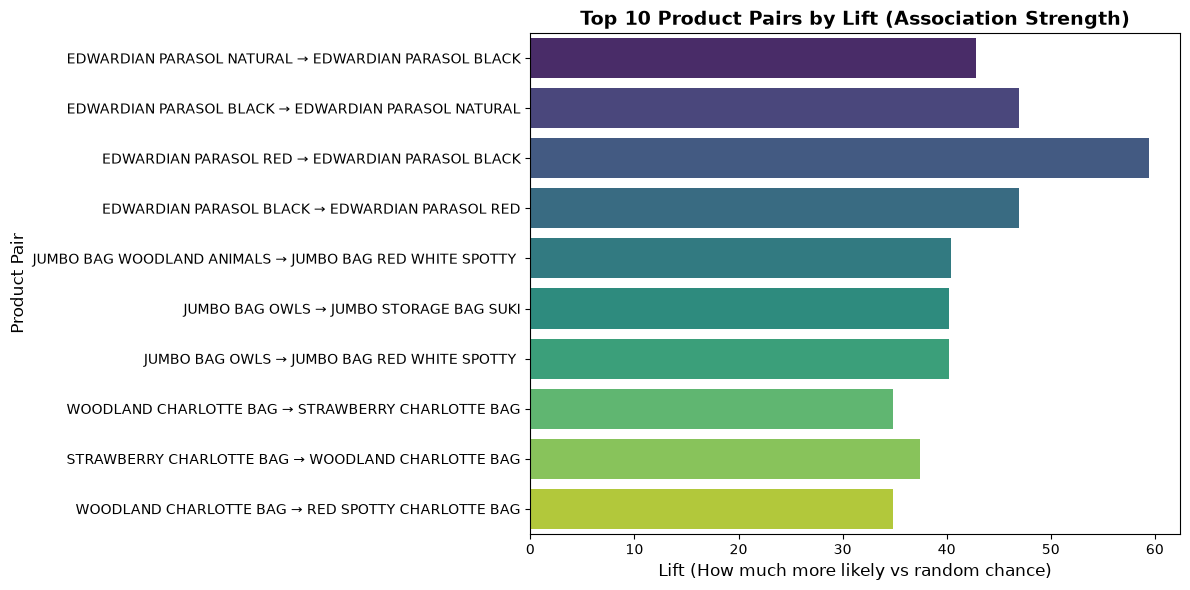

✅ Saved: top_pairs_lift_chart.png


In [ ]:
import seaborn as sns

# Top 10 pairs
top_10 = final_rules.head(10).copy()
top_10["Pair"] = top_10["If_Buys_Product"] + " → " + top_10["Then_Also_Buys_Product"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x="Lift", y="Pair", palette="viridis")
plt.title(
    "Top 10 Product Pairs by Lift (Association Strength)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Lift (How much more likely vs random chance)", fontsize=12)
plt.ylabel("Product Pair", fontsize=12)
plt.tight_layout()
plt.savefig("./assets/top_pairs_lift_chart.png", dpi=150)
plt.show()

print("✅ Saved: top_pairs_lift_chart.png")